# Decoding the 2026 Tamil Nadu Assembly Election

## Headline

### The Election That Reshaped Tamil Nadu's Political Balance

---

## Research Questions

1. Geographic Story
2. Flip Story

---

## Notebook Roadmap

1. Load Data
2. Data Preparation
3. Geographic Story
4. Flip Story
5. Connecting the Stories
6. Editorial Recommendation

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [3]:
results_2021 = pd.read_csv("../data/tn_2021_results.csv")
results_2026 = pd.read_csv("../data/tn_2026_results.csv")
master = pd.read_csv("../data/constituency_master.csv")

## Data Preparation

The raw data contains one row per candidate.

To analyze seat distribution, we first identify the winning candidate in each constituency.

In [8]:
winner2021 = (
    results_2021
    .sort_values('votes', ascending=False)
    .groupby('ac_number')
    .first()
    .reset_index()
)

winner2021.head()

,ac_number,constituency,candidate,party,votes,turnout,reserved,region
0,1,Gummidipundi,GOVINDARAJAN T.J,DMK,126452,78.08,GEN,Chennai Metro
1,2,Ponneri,DURAI. CHANDRASEKAR,INC,94528,78.20,SC,Chennai Metro
2,3,Tiruttani,S.Chandran,DMK,120314,78.76,GEN,Chennai Metro
3,4,Thiruvallur,"RAAJENDRAN, V.G.",DMK,107709,77.20,GEN,Chennai Metro
4,5,Poonamallee,Krishnaswamy A,DMK,149578,72.99,SC,Chennai Metro


In [11]:
winner2026 = (
    results_2026
    .sort_values('votes', ascending=False)
    .groupby('ac_number')
    .first()
    .reset_index()
)

winner2026.head()

,ac_number,constituency,candidate,party,votes,turnout,reserved,region
0,1,Gummidipoondi,S.VIJAYAKUMAR,TVK,94320,NaN,GEN,Chennai Metro
1,2,Ponneri,DR.RAVI.M.S,TVK,110439,NaN,SC,Chennai Metro
2,3,Tiruttani,G.HARI,AIADMK,89169,NaN,GEN,Chennai Metro
3,4,Thiruvallur,DR. T. ARUNKUMAR,TVK,92190,NaN,GEN,Chennai Metro
4,5,Poonamallee,PRAKASAM.R,TVK,161309,NaN,SC,Chennai Metro


# Geographic Story

If Tamil Nadu's political balance changed in 2026, the first place to look is geography.

Rather than looking at the state as a whole, we examine how seats were distributed across the six regions of Tamil Nadu:

- Chennai Metro
- North
- Central
- Kongu
- Delta
- South

The objective is to identify where political power shifted between 2021 and 2026.

In [13]:
winner2021['party'].value_counts()

party
DMK       133
AIADMK     66
INC        18
PMK         5
VCK         4
BJP         4
CPI         2
CPI(M)      2
Name: count, dtype: int64

In [14]:
winner2026['party'].value_counts()

party
TVK       108
DMK        59
AIADMK     47
INC         5
PMK         4
IUML        2
CPI         2
VCK         2
CPI(M)      2
BJP         1
DMDK        1
AMMK        1
Name: count, dtype: int64

In [16]:
winner2021['party_group'] = winner2021['party'].apply(
    lambda x: x if x in ['DMK', 'AIADMK', 'TVK'] else 'Others'
)

winner2026['party_group'] = winner2026['party'].apply(
    lambda x: x if x in ['DMK', 'AIADMK', 'TVK'] else 'Others'
)

In [18]:
regional_2021 = pd.crosstab(
    winner2021['region'],
    winner2021['party_group']
)

regional_2021

party_group,AIADMK,DMK,Others
region,,,
Central,15,21,5
Chennai Metro,0,29,3
Delta,4,23,6
Kongu,19,10,4
North,12,19,6
South,16,31,11


In [19]:
regional_2026 = pd.crosstab(
    winner2026['region'],
    winner2026['party_group']
)

regional_2026

party_group,AIADMK,DMK,Others,TVK
region,,,,
Central,15,8,6,12
Chennai Metro,1,2,0,29
Delta,4,14,5,10
Kongu,7,9,1,16
North,15,4,3,15
South,5,22,5,26


In [21]:
regional_2021 = regional_2021.reindex(
    columns=['DMK', 'AIADMK', 'TVK', 'Others'],
    fill_value=0
)

regional_2026 = regional_2026.reindex(
    columns=['DMK', 'AIADMK', 'TVK', 'Others'],
    fill_value=0
)


party_group,DMK,AIADMK,TVK,Others
region,,,,
Central,21,15,0,5
Chennai Metro,29,0,0,3
Delta,23,4,0,6
Kongu,10,19,0,4
North,19,12,0,6
South,31,16,0,11


In [31]:
regional_shift = regional_2026 - regional_2021

annot_labels = regional_shift.map(
    lambda x: f"+{x}" if x > 0 else str(x)
)


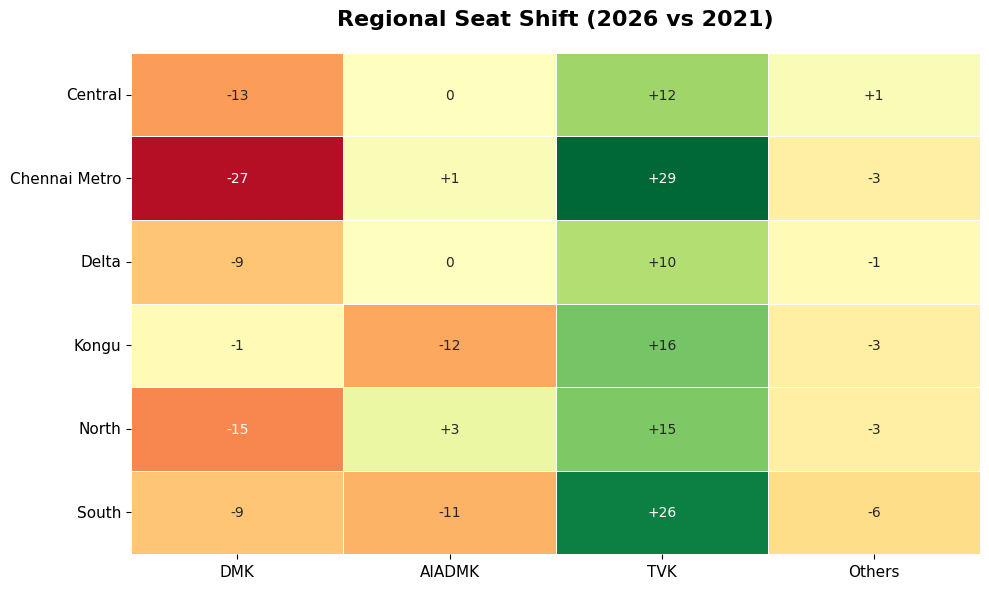

In [33]:
annot_labels = regional_shift.map(
    lambda x: f"+{x}" if x > 0 else str(x)
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    regional_shift,
    annot=annot_labels,
    fmt="",
    cmap="RdYlGn",
    center=0,
    cbar=False,
    linewidths=0.5,
    linecolor="white"
)

# Title
plt.title(
    "Regional Seat Shift (2026 vs 2021)",
    fontsize=16,
    weight="bold",
    pad=20
)

# Remove axis titles
plt.xlabel("")
plt.ylabel("")

# Keep labels horizontal
plt.xticks(rotation=0, fontsize=11)
plt.yticks(rotation=0, fontsize=11)

# Remove extra whitespace
plt.tight_layout()

plt.show()

In [36]:
regional_2021 = pd.crosstab(
    winner2021['region'],
    winner2021['party_group']
)

regional_2026 = pd.crosstab(
    winner2026['region'],
    winner2026['party_group']
)

In [37]:
regional_2021_pct = (
    regional_2021
    .div(regional_2021.sum(axis=1), axis=0)
    * 100
).round(0)

regional_2026_pct = (
    regional_2026
    .div(regional_2026.sum(axis=1), axis=0)
    * 100
).round(0)

In [39]:
party_order = ['AIADMK', 'DMK', 'Others', 'TVK']

regional_2021_pct = regional_2021_pct.reindex(
    columns=party_order,
    fill_value=0
)

regional_2026_pct = regional_2026_pct.reindex(
    columns=party_order,
    fill_value=0
)

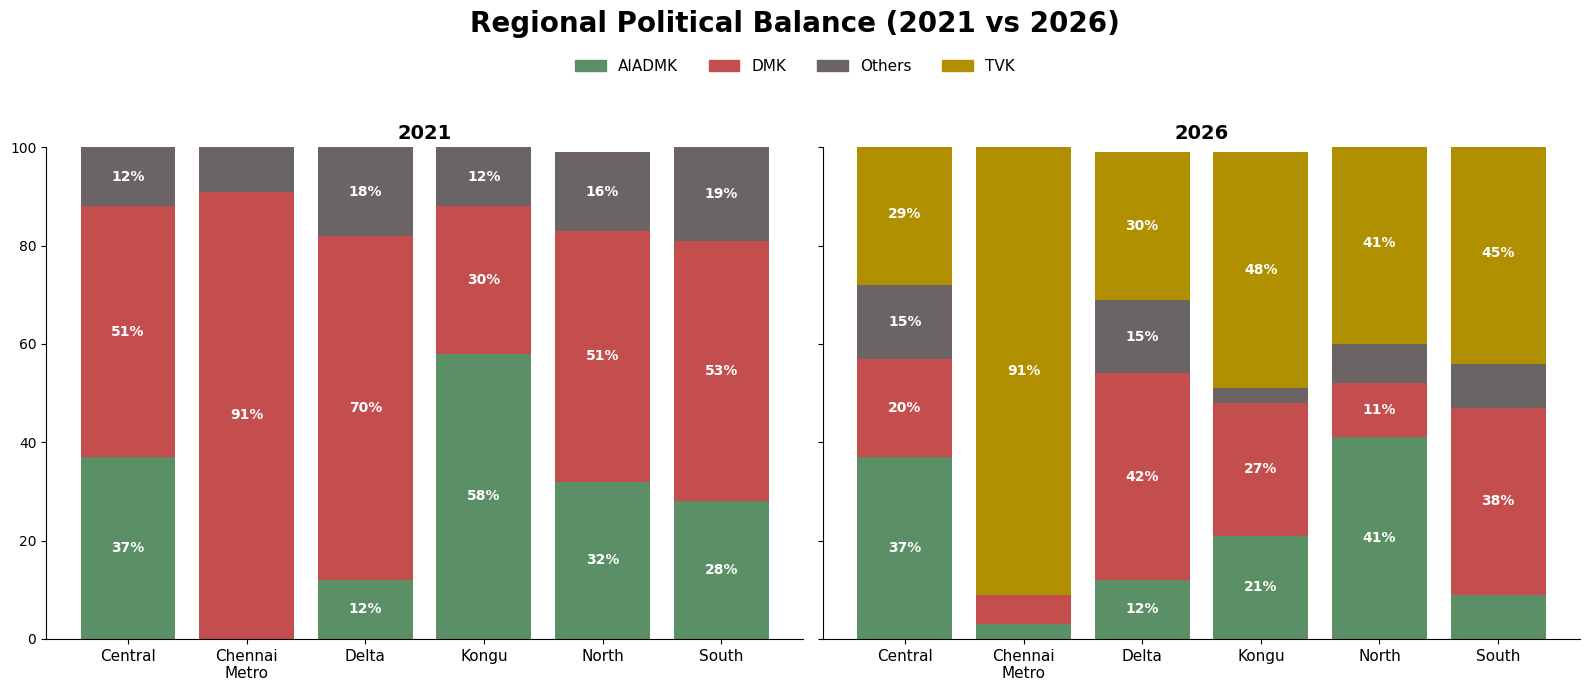

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Region Labels
# -----------------------------

region_labels = [
    'Central',
    'Chennai\nMetro',
    'Delta',
    'Kongu',
    'North',
    'South'
]

regional_2021_pct.index = region_labels
regional_2026_pct.index = region_labels

# -----------------------------
# Party Order & Colors
# -----------------------------

party_order = ['AIADMK', 'DMK', 'Others', 'TVK']

colors = {
    'AIADMK': '#5B8F65',
    'DMK': '#C44E4E',
    'Others': '#6B6464',
    'TVK': '#B08F00'
}

# -----------------------------
# Create Figure
# -----------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 7),
    sharey=True
)

# =============================
# 2021
# =============================

bottom = np.zeros(len(regional_2021_pct))

for party in party_order:

    values = regional_2021_pct[party].values

    axes[0].bar(
        regional_2021_pct.index,
        values,
        bottom=bottom,
        color=colors[party],
        width=0.8
    )

    # Data labels
    for i, v in enumerate(values):

        if v >= 10:

            axes[0].text(
                i,
                bottom[i] + (v / 2),
                f"{int(v)}%",
                ha='center',
                va='center',
                color='white',
                fontsize=10,
                fontweight='bold'
            )

    bottom += values

# =============================
# 2026
# =============================

bottom = np.zeros(len(regional_2026_pct))

for party in party_order:

    values = regional_2026_pct[party].values

    axes[1].bar(
        regional_2026_pct.index,
        values,
        bottom=bottom,
        color=colors[party],
        width=0.8
    )

    # Data labels
    for i, v in enumerate(values):

        if v >= 10:

            axes[1].text(
                i,
                bottom[i] + (v / 2),
                f"{int(v)}%",
                ha='center',
                va='center',
                color='white',
                fontsize=10,
                fontweight='bold'
            )

    bottom += values

# =============================
# Formatting
# =============================

axes[0].set_title(
    "2021",
    fontsize=14,
    fontweight='bold'
)

axes[1].set_title(
    "2026",
    fontsize=14,
    fontweight='bold'
)

for ax in axes:

    ax.set_ylim(0, 100)

    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.tick_params(
        axis='x',
        rotation=0,
        labelsize=11
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Main Title

fig.suptitle(
    "Regional Political Balance (2021 vs 2026)",
    fontsize=20,
    fontweight='bold',
    y=0.98
)

# Legend

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=colors[p])
    for p in party_order
]

fig.legend(
    legend_handles,
    party_order,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.93),
    ncol=4,
    frameon=False,
    fontsize=11
)

plt.tight_layout(rect=[0, 0, 1, 0.90])

plt.show()

## Geographic Story: A Statewide Shift in Political Power

### Key Observations

* TVK was the only major formation to gain seats across all six regions of Tamil Nadu.
* The largest shift occurred in Chennai Metro, where TVK gained 29 seats while DMK lost 27 seats.
* South Tamil Nadu recorded the second-largest shift, with TVK gaining 26 seats.
* Kongu, traditionally an AIADMK stronghold, saw TVK gain 16 seats while AIADMK lost 12 seats.
* Similar seat redistribution patterns were visible across North, Central, and Delta regions.

### Key Takeaway

* The 2026 election was not driven by a single regional wave.
* Political power shifted across every region of Tamil Nadu.
* TVK emerged as the primary beneficiary of this statewide redistribution of seats.
* The geographic evidence supports the headline: **"The Election That Reshaped Tamil Nadu's Political Balance."**
